# EDA

In [1]:
from google.colab import files

uploaded = files.upload()

Saving questions.csv to questions.csv


In [2]:
import pandas as pd

df = pd.read_csv("questions.csv")
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [3]:
df.shape

(404290, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [5]:
df.columns

Index(['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate'], dtype='object')

In [6]:
df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,1
question2,2
is_duplicate,0


In [7]:
df=df.dropna()

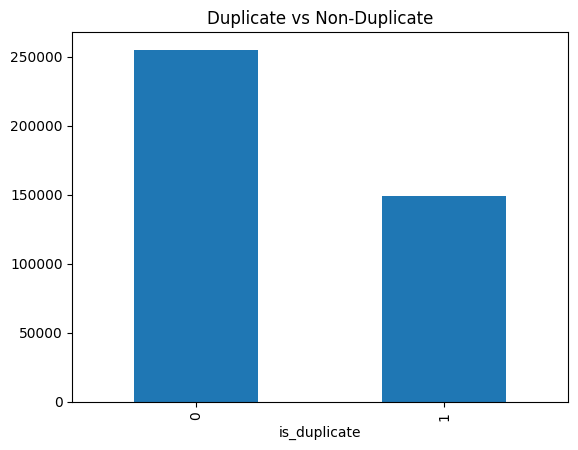

In [8]:
import matplotlib.pyplot as plt

df['is_duplicate'].value_counts().plot(kind='bar')
plt.title("Duplicate vs Non-Duplicate")
plt.show()

In [9]:
df['len_q1'] = df['question1'].apply(len)
df['len_q2'] = df['question2'].apply(len)

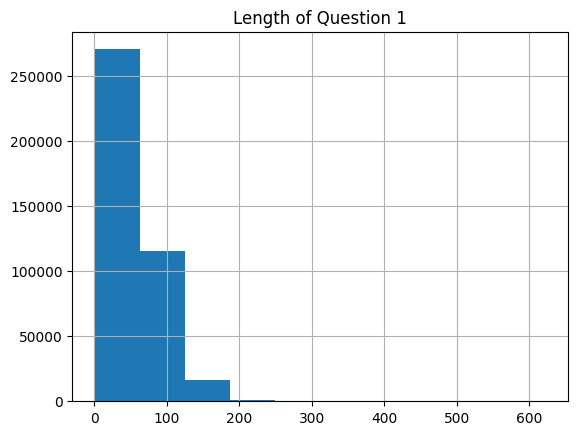

In [10]:
df['len_q1'].hist()
plt.title("Length of Question 1")
plt.show()

In [11]:
from collections import Counter

text = " ".join(df['question1'].astype(str))
words = text.split()

Counter(words).most_common(10)

[('the', 186114),
 ('What', 147489),
 ('is', 108147),
 ('a', 100298),
 ('I', 100124),
 ('How', 99941),
 ('to', 97855),
 ('in', 94407),
 ('of', 79312),
 ('do', 68336)]

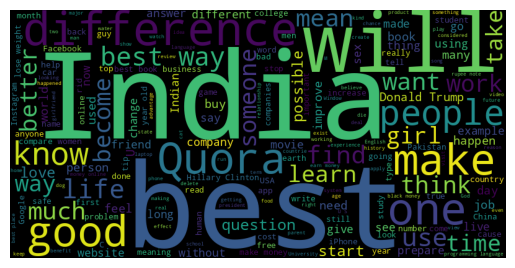

In [12]:
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis('off')
plt.show()

In [13]:
df['len_q1'].mean(), df['len_q2'].mean()

(np.float64(59.53699723216428), np.float64(60.1085070754192))

# Imports

In [14]:
import re
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from difflib import SequenceMatcher
from scipy.sparse import hstack
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation

# Cleaning

In [15]:
def clean_text(text):
    text = str(text).lower()

    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"n't", " not", text)

    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'ll", " will", text)

    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


df['question1'] = df['question1'].apply(clean_text)
df['question2'] = df['question2'].apply(clean_text)

# Feature Function

In [16]:
def jaccard_sim(q1, q2):
    s1, s2 = set(q1.split()), set(q2.split())
    if not s1 or not s2:
        return 0
    return len(s1 & s2) / len(s1 | s2)

def word_share(q1, q2):
    s1, s2 = set(q1.split()), set(q2.split())
    return len(s1 & s2) / (len(s1) + len(s2) + 1)

def seq_sim(q1, q2):
    return SequenceMatcher(None, q1, q2).ratio()

def length_diff(q1, q2):
    return abs(len(q1.split()) - len(q2.split()))

def first_word_match(q1, q2):
    q1, q2 = q1.split(), q2.split()
    if len(q1) == 0 or len(q2) == 0:
        return 0
    return int(q1[0] == q2[0])

# TF-IDF

In [17]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5,
    sublinear_tf=True,
    dtype=np.float32
)

# fit ONLY once on all text
all_text = pd.concat([df['question1'], df['question2']])
tfidf.fit(all_text)

TfidfVectorizer(dtype=<class 'numpy.float32'>, max_features=5000, min_df=5,
                ngram_range=(1, 2), sublinear_tf=True)

# Search Function (Top-K Similar Questions)

In [18]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def get_top_k_similar(query, df, tfidf, k=3):

    # Cleaning
    query = clean_text(query)

    # Transform query
    query_vec = tfidf.transform([query])

    # Transform corpus
    corpus_vecs = tfidf.transform(df['question1'])

    # Cosine similarity
    sims = cosine_similarity(query_vec, corpus_vecs)[0]

    # Top-k indices
    top_idx = sims.argsort()[-k:][::-1]


    results = df.iloc[top_idx][['question1', 'question2']].copy()
    results['score'] = sims[top_idx]

    return results

## Feature Engineering

In [19]:
df['jaccard_sim'] = df.apply(lambda x: jaccard_sim(x['question1'], x['question2']), axis=1)
df['word_share'] = df.apply(lambda x: word_share(x['question1'], x['question2']), axis=1)
df['seq_sim'] = df.apply(lambda x: seq_sim(x['question1'], x['question2']), axis=1)
df['len_diff'] = df.apply(lambda x: length_diff(x['question1'], x['question2']), axis=1)
df['first_word_match'] = df.apply(lambda x: first_word_match(x['question1'], x['question2']), axis=1)

In [20]:
import numpy as np
from scipy.sparse import hstack

# TF-IDF
q1_tfidf = tfidf.transform(df['question1'])
q2_tfidf = tfidf.transform(df['question2'])

# =========================
# FAST cosine approximation (VERY FAST)
# =========================
cosine_vals = np.array(
    (q1_tfidf.multiply(q2_tfidf)).sum(axis=1)
).ravel()

df['cosine_similarity'] = cosine_vals

# =========================
# FEATURES
# =========================
features = [
    'jaccard_sim',
    'word_share',
    'seq_sim',
    'len_diff',
    'first_word_match',
    'cosine_similarity'
]

# =========================
# FINAL MATRIX
# =========================
X = hstack([
    q1_tfidf,
    q2_tfidf,
    df[features].values
])

y = df['is_duplicate']

# Modeling

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[early_stopping(50), log_evaluation(50)]
)

[LightGBM] [Info] Number of positive: 119410, number of negative: 204019
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 32.768475 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 709091
[LightGBM] [Info] Number of data points in the train set: 323429, number of used features: 10006
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_logloss: 0.50612
[100]	valid_0's binary_logloss: 0.474605
[150]	valid_0's binary_logloss: 0.458904
[200]	valid_0's binary_logloss: 0.448891
[250]	valid_0's binary_logloss: 0.441297
[300]	valid_0's binary_logloss: 0.435377
[350]	valid_0's binary_logloss: 0.430837
[400]	valid_0's binary_logloss: 0.426738
[450]	valid_0's binary_logloss: 0.423394
[500]	v

LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=1000,
               random_state=42)

In [22]:
def predict_pair(q1, q2):

    q1 = clean_text(q1)
    q2 = clean_text(q2)

    jacc = jaccard_sim(q1, q2)
    wshare = word_share(q1, q2)
    seq = seq_sim(q1, q2)
    ldiff = length_diff(q1, q2)
    first = first_word_match(q1, q2)

    q1_vec = tfidf.transform([q1])
    q2_vec = tfidf.transform([q2])

    cos = cosine_similarity(q1_vec, q2_vec)[0][0]

    feat = np.array([[jacc, wshare, seq, ldiff, first, cos]])

    X_new = hstack([q1_vec, q2_vec, feat])

    pred = lgb_model.predict(X_new)[0]
    prob = lgb_model.predict_proba(X_new)[0][1]

    return pred, prob

In [25]:
# Predictions on test set
y_pred = lgb_model.predict(X_test)

# Probabilities
y_prob = lgb_model.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [26]:
# evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred = lgb_model.predict(X_test)

# Probabilities
y_prob = lgb_model.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy : 0.8000
Precision: 0.6801
Recall   : 0.8651
F1 Score : 0.7616
ROC AUC  : 0.8987

Confusion Matrix:
[[38858 12147]
 [ 4026 25827]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.76      0.83     51005
           1       0.68      0.87      0.76     29853

    accuracy                           0.80     80858
   macro avg       0.79      0.81      0.79     80858
weighted avg       0.82      0.80      0.80     80858



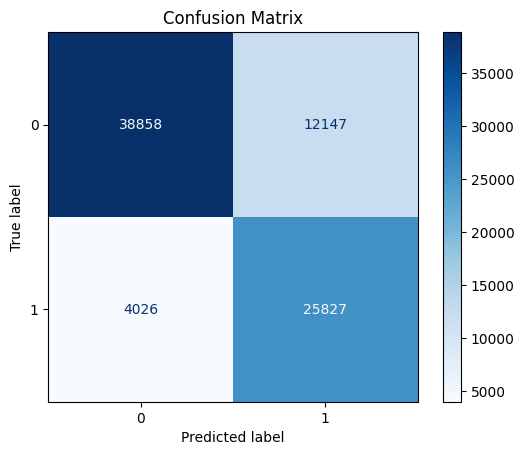

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

# Testing

In [28]:
q1 = "How do I lose weight quickly?"
q2 = "What is the fastest way to lose weight?"

pred, prob = predict_pair(q1, q2)

print("Probability:", prob)

Probability: 0.9806444964542432


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


In [29]:
query = "What is the best way to start programming?"

top_results = get_top_k_similar(query, df, tfidf, k=3)

print(top_results)

                                                question1  \
204299  what is the best way to start a programming ca...   
251458           what is the best way to start meditating   
221277                what is the best way to start a caf   

                                  question2     score  
204299  how do i begin a programming career  0.924935  
251458        how should i start meditating  0.923228  
221277                how do i start a cafe  0.923228  


In [30]:
import joblib

joblib.dump(lgb_model, "lgb_model.pkl")
print("Model saved")

joblib.dump(tfidf, "tfidf.pkl")
print("TF-IDF saved")

Model saved
TF-IDF saved
